In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os 

os.chdir("/Users/AlanHDLR/Desktop")

from sklearn.cluster import KMeans

dataset = pd.read_csv("iris.csv")
dataset

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
fields = dataset.iloc[:, 0:4].values
print(fields)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
# Calculara la inercia que hay, tomando en cuenta los puntos que hay
wcss = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

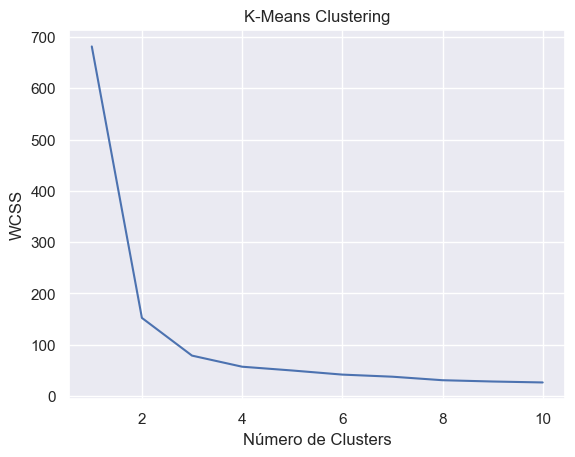

In [27]:
# Graficación del "Codo de Jambu"
sb.set()
plt.plot(range(1,11), wcss)
plt.title("K-Means Clustering")
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS") # Weighted cluster sum of squares

In [29]:
# Criterio de Silueta ("Silhouette")
from sklearn import datasets
from sklearn.metrics import silhouette_score

In [31]:
X = dataset.iloc[:, 0:4].to_numpy()
for j in range (2,11):
    kmeans = KMeans(n_clusters = j, random_state = 2)
    kmeans.fit_predict(X)
    # Calculamso el score de Silueta
    score = silhouette_score(X, kmeans.labels_, metric = 'euclidean')
    print("Score Silhouette;", "k = ", j, ":", score)

Score Silhouette; k =  2 : 0.6810461692117465
Score Silhouette; k =  3 : 0.5528190123564101
Score Silhouette; k =  4 : 0.4980505049972879
Score Silhouette; k =  5 : 0.4585253709034502
Score Silhouette; k =  6 : 0.4777970036973851
Score Silhouette; k =  7 : 0.456416020556581
Score Silhouette; k =  8 : 0.3385250255429534
Score Silhouette; k =  9 : 0.3238105372029922
Score Silhouette; k =  10 : 0.31160656853581714


# Aplicación de PCA

In [34]:
fields2 = dataset.iloc[:, 0:4].values
print(fields2)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [36]:
# Utilización de PCA para convertir de 4 columnas a 2
from sklearn import decomposition

pca = decomposition.PCA(n_components = 2)
pca.fit(fields2)
fields2 = pca.transform(fields2)
fields2

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [38]:
# Calculo de los centroides
# Calculara la inercia que hay, tomando en cuenta los puntos que hay
wcss2 = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)

    wcss2.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

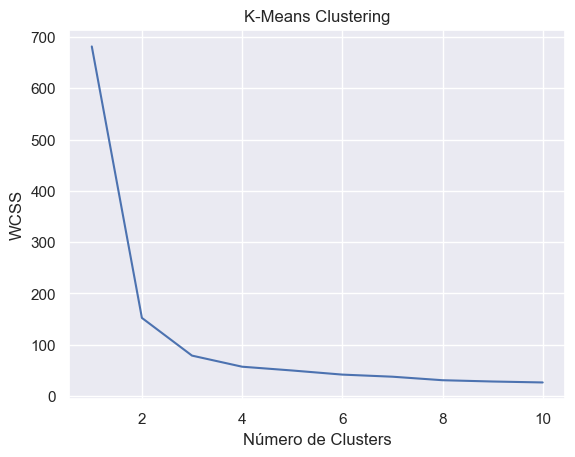

In [40]:
# Graficación del "Codo de Jambu"
sb.set()
plt.plot(range(1,11), wcss2)
plt.title("K-Means Clustering")
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS") # Weighted cluster sum of squares

In [42]:
X = dataset.iloc[:, 0:4].to_numpy()
for j in range (2,11):
    kmeans = KMeans(n_clusters = j, random_state = 2)
    kmeans.fit_predict(X)
    # Calculamso el score de Silueta
    score = silhouette_score(X, kmeans.labels_, metric = 'euclidean')
    print("Score Silhouette;", "k = ", j, ":", score)

Score Silhouette; k =  2 : 0.6810461692117465
Score Silhouette; k =  3 : 0.5528190123564101
Score Silhouette; k =  4 : 0.4980505049972879
Score Silhouette; k =  5 : 0.4585253709034502
Score Silhouette; k =  6 : 0.4777970036973851
Score Silhouette; k =  7 : 0.456416020556581
Score Silhouette; k =  8 : 0.3385250255429534
Score Silhouette; k =  9 : 0.3238105372029922
Score Silhouette; k =  10 : 0.31160656853581714


In [52]:
kmeans = KMeans(n_clusters= 2, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


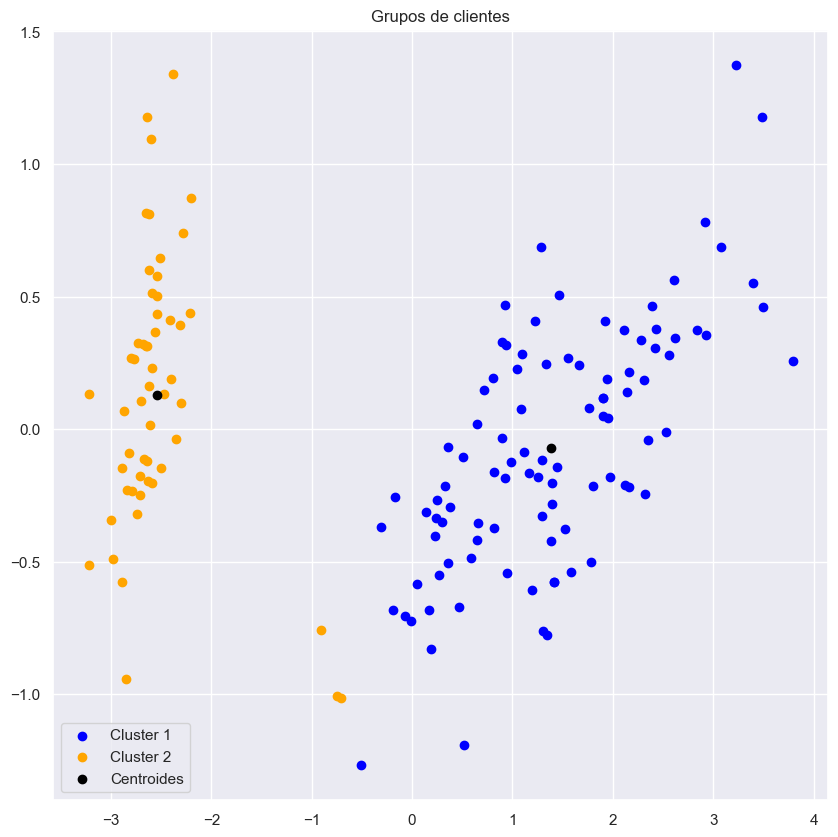

In [56]:
# Grafico con 2 clusters
plt.figure(figsize = (10,10))
plt.scatter(fields2[cluster_values == 0,0], fields2[cluster_values == 0,1], color = "blue", label ='Cluster 1')
plt.scatter(fields2[cluster_values == 1,0], fields2[cluster_values == 1,1], color = "orange", label ='Cluster 2')
#plt.scatter(fields2[cluster_values == 2,0], fields2[cluster_values == 2,1], color = "green", label ='Cluster 3')

# Centroides
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color = 'black', label = 'Centroides')

plt.title("Grupos de clientes")
plt.xlabel = "Annuel income"
plt.ylabel = "Spending Score"
plt.legend()

In [58]:
kmeans = KMeans(n_clusters= 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


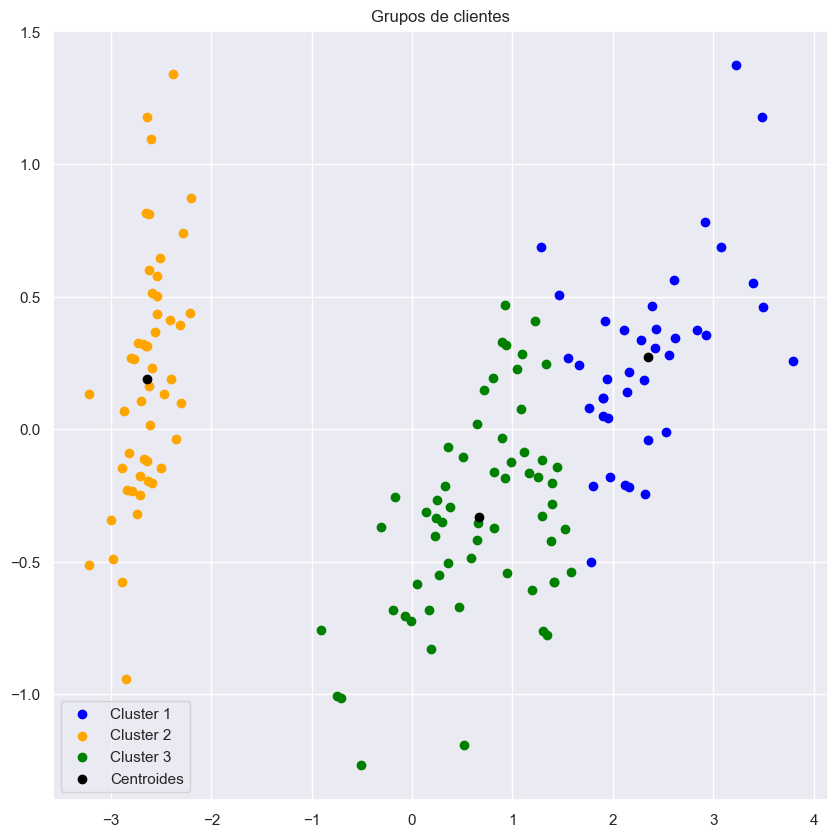

In [60]:
# Grafico con 3 clusters
plt.figure(figsize = (10,10))
plt.scatter(fields2[cluster_values == 0,0], fields2[cluster_values == 0,1], color = "blue", label ='Cluster 1')
plt.scatter(fields2[cluster_values == 1,0], fields2[cluster_values == 1,1], color = "orange", label ='Cluster 2')
plt.scatter(fields2[cluster_values == 2,0], fields2[cluster_values == 2,1], color = "green", label ='Cluster 3')

# Centroides
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color = 'black', label = 'Centroides')

plt.title("Grupos de clientes")
plt.xlabel = "Annuel income"
plt.ylabel = "Spending Score"
plt.legend()